# Diabetes Dataset LightGBM 회귀

## 개요
- scikit-learn `load_diabetes` 데이터셋으로 **당뇨병 진행도(연속값)** 예측
- LightGBM Regressor로 성능 향상 및 하이퍼파라미터 최적화(GridSearchCV)
- 평가 지표: **R2 Score**, **RMSE**

## 주요 단계
1. 데이터 로드 및 분리
2. LightGBM Regressor 설정
3. GridSearchCV 최적화
4. 성능 평가 및 피처 중요도 분석

## 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from lightgbm import LGBMRegressor, plot_importance
from sklearn.metrics import r2_score, mean_squared_error

## 1. 데이터 로드

**Diabetes 데이터셋**
- 442개 샘플, 10개 피처
- 당뇨병 진행도 예측 (연속값)

In [2]:
print("Loading Diabetes Dataset...")
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

print(f"데이터 크기: {X.shape}")
print(f"타깃 크기: {y.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"타깃(연속값) 요약: min={y.min():.2f}, max={y.max():.2f}, mean={y.mean():.2f}")

Loading Diabetes Dataset...
데이터 크기: (442, 10)
타깃 크기: (442,)
피처 목록: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
타깃(연속값) 요약: min=25.00, max=346.00, mean=152.13


**데이터 샘플 확인**

In [3]:
# 데이터 샘플
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

기술 통계:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072

**학습/테스트 데이터 분리**

In [4]:
# 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (353, 10), Test: (89, 10)


## 2. LightGBM Regressor

**LightGBM 회귀 특징**
- Leaf-wise: 리프 중심 분할
- 빠른 학습: 히스토그램 기반
- 메모리 효율: 대용량 데이터 처리
- 목적 함수: MSE 최소화

**하이퍼파라미터**
- n_estimators: 트리 개수
- learning_rate: 학습률
- num_leaves: 최대 리프 개수
- max_depth: 트리 최대 깊이
- min_child_samples: 리프 최소 데이터 수

**모델 설정**

In [5]:
# LightGBM Regressor
# verbose=-1: 경고 메시지 출력 억제
lgbm_reg = LGBMRegressor(
    random_state=42,
    verbose=-1
)

print("LightGBM Regressor 생성")
print(f"기본 설정: n_estimators=100, learning_rate=0.1, num_leaves=31")

LightGBM Regressor 생성
기본 설정: n_estimators=100, learning_rate=0.1, num_leaves=31


## 3. GridSearchCV 하이퍼파라미터 탐색

**파라미터 그리드**
- n_estimators: [100, 200, 300]
- learning_rate: [0.01, 0.05, 0.1]
- num_leaves: [31, 60]
- max_depth: [-1, 10]
- min_child_samples: [20, 30]

**파라미터 의미**
- n_estimators: 더 많으면 정확하지만 느림
- learning_rate: 낮을수록 안정적
- num_leaves: 과적합 제어

In [6]:
# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 60],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 30]
}

print("파라미터 그리드:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combinations = 1
for values in param_grid.values():
    total_combinations *= len(values)
print(f"\n총 조합 수: {total_combinations}개")

파라미터 그리드:
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.05, 0.1]
  num_leaves: [31, 60]
  max_depth: [-1, 10]
  min_child_samples: [20, 30]

총 조합 수: 72개


In [7]:
# GridSearchCV
print("\nTuning LightGBM Regressor...")
print("(교차검증 수행 중...)\n")

grid_reg = GridSearchCV(
    lgbm_reg,
    param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train, y_train)
print("\nGridSearchCV 완료!")


Tuning LightGBM Regressor...
(교차검증 수행 중...)

Fitting 5 folds for each of 72 candidates, totalling 360 fits

GridSearchCV 완료!


## 4. 최적화 결과 분석

**최적 모델 정보**

In [8]:
# 최적 모델 추출
best_reg = grid_reg.best_estimator_

print("[최적화 결과]")
print(f"Best R2 Score (Train CV): {grid_reg.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in grid_reg.best_params_.items():
    print(f"  {param}: {value}")

[최적화 결과]
Best R2 Score (Train CV): 0.4304

Best Parameters:
  learning_rate: 0.01
  max_depth: -1
  min_child_samples: 20
  n_estimators: 300
  num_leaves: 31


**GridSearchCV 상위 결과**

In [9]:
# 상위 5개 결과
cv_results = pd.DataFrame(grid_reg.cv_results_)
top_results = cv_results.nlargest(5, 'mean_test_score')[[
    'param_n_estimators',
    'param_learning_rate',
    'param_num_leaves',
    'param_max_depth',
    'param_min_child_samples',
    'mean_test_score',
    'std_test_score'
]]

print("\n상위 5개 파라미터 조합:")
print(top_results.to_string(index=False))


상위 5개 파라미터 조합:
 param_n_estimators  param_learning_rate  param_num_leaves  param_max_depth  param_min_child_samples  mean_test_score  std_test_score
                300                 0.01                31               -1                       20         0.430369        0.063688
                300                 0.01                60               -1                       20         0.430369        0.063688
                300                 0.01                31               10                       20         0.430369        0.063688
                300                 0.01                60               10                       20         0.430369        0.063688
                100                 0.05                31               -1                       20         0.425255        0.073633


## 5. 테스트 데이터 평가

**예측 및 성능 평가**

In [10]:
# 테스트 데이터 예측
y_pred = best_reg.predict(X_test)

# 평가 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.4f}")
print(f"Test R2 Score: {r2:.4f}")

Test RMSE: 53.7480
Test R2 Score: 0.4547


## 6. 피처 중요도 분석

**LightGBM 피처 중요도 타입**
- split: 피처가 사용된 횟수
- gain: 평균 손실 감소량 (기본, 추천)

**gain 추천 이유**
- 실제 예측 개선 정도 반영
- 가장 해석 가능

**LightGBM 내장 시각화**

<Figure size 1000x800 with 0 Axes>

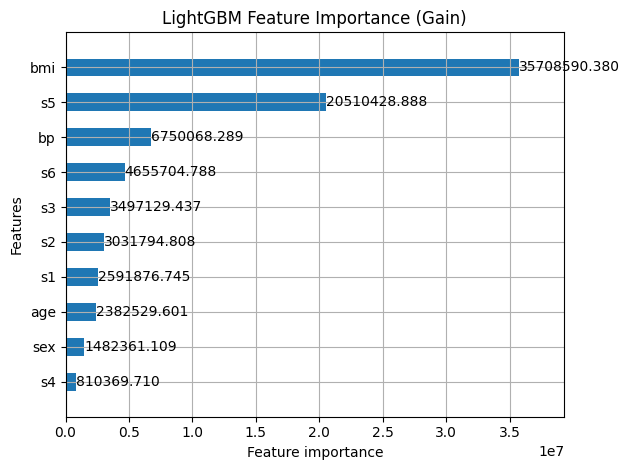

In [13]:
# LightGBM plot_importance
plt.figure(figsize=(10, 8))
plot_importance(best_reg, max_num_features=10,
                importance_type='gain', height=0.5)
plt.title("LightGBM Feature Importance (Gain)")
plt.tight_layout()
plt.show()

**수동 피처 중요도 추출 및 시각화**


피처 중요도 순위:
Feature  Importance
    bmi         763
     s5         552
     bp         521
     s6         370
     s1         349
     s3         313
     s2         304
    age         288
    sex         189
     s4          85


/tmp/ipython-input-2221174224.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')


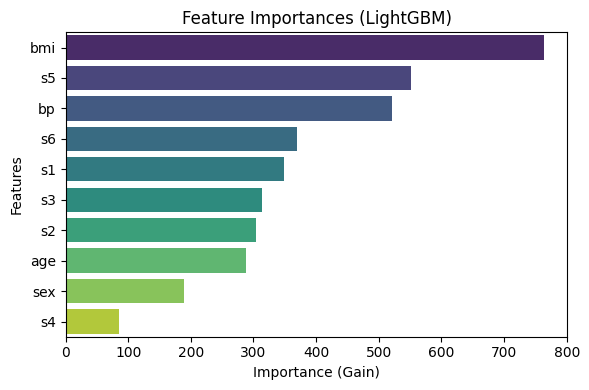

In [17]:
# 피처 중요도 추출
importances = best_reg.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 중요도 정렬
importance_df = pd.DataFrame({
    'Feature': feature_names[indices],
    'Importance': importances[indices]
})

print("\n피처 중요도 순위:")
print(importance_df.to_string(index=False))

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis')
plt.title("Feature Importances (LightGBM)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()